# Fine-Tuning de Modelos en Azure AI Foundry
## AzureDataBot — Asistente Técnico Especializado en Azure Data Services

---

## Sección 1: Introducción y Contexto

### Descripción del caso de uso

**AzureDataBot** es un asistente técnico especializado en el ecosistema de datos de Azure: Azure SQL Database, Azure Data Factory, Databricks, Microsoft Fabric y arquitecturas de datos cloud.

**Problema que resuelve:** Los modelos de lenguaje base (GPT-4o-mini sin fine-tune) responden preguntas técnicas de Azure de forma correcta pero genérica. Un modelo fine-tuned con este dataset:
- Adopta el tono técnico y directo de un data engineer senior
- Siempre incluye ejemplos de código T-SQL o Python ejecutables
- Responde con estructura consistente (diagnóstico → solución → código → casos de uso)
- Incluye referencias a certificaciones (DP-300, DP-700) cuando es relevante
- Da contexto práctico además de la respuesta teórica

### Dataset

- **Archivo de entrenamiento:** `training_set.jsonl` — 33 ejemplos
- **Archivo de validación:** `validation_set.jsonl` — 8 ejemplos
- **Total:** 41 pares conversacionales
- **Formato:** JSONL con roles `system`, `user`, `assistant`
- **Dominio:** Azure SQL, ADF, Databricks, Spark, Microsoft Fabric, arquitecturas de datos
- **Modelo base:** `gpt-4o-mini`

---
## Configuración

Crea un archivo `.env` en el directorio raíz:
```
AZURE_OPENAI_ENDPOINT=https://<tu-recurso>.openai.azure.com/
AZURE_OPENAI_API_KEY=<tu-api-key>
AZURE_OPENAI_API_VERSION=2024-05-01-preview
BASE_DEPLOYMENT=gpt-4o-mini
```

> El fine-tuning de GPT-4o-mini requiere que tu recurso Azure OpenAI esté en una región que lo soporte (East US, North Central US, Sweden Central o West Europe). Verifica en el portal antes de ejecutar.

In [51]:
!pip install openai python-dotenv matplotlib pandas --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import time
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dotenv import load_dotenv
from openai import AzureOpenAI

load_dotenv()

client = AzureOpenAI(
    azure_endpoint=os.getenv('AZURE_OPENAI_ENDPOINT'),
    api_key=os.getenv('AZURE_OPENAI_API_KEY'),
    api_version=os.getenv('AZURE_OPENAI_API_VERSION', '2024-05-01-preview')
)

BASE_DEPLOYMENT = os.getenv('BASE_DEPLOYMENT', 'gpt-4o-mini')

print(f'Cliente configurado.')
print(f'Endpoint: {os.getenv("AZURE_OPENAI_ENDPOINT")}')
print(f'Modelo base: {BASE_DEPLOYMENT}')

Cliente configurado.
Endpoint: https://ai-sergiorincon0872ai045504941434.openai.azure.com/
Modelo base: gpt-4.1-mini


---
## Sección 2: Proceso de Fine-Tuning (Modalidad Python SDK)

### 2.1 — Validación y análisis del dataset

In [3]:
def analizar_dataset(ruta: str) -> dict:
    """Analiza un archivo JSONL de fine-tuning y devuelve estadísticas."""
    ejemplos = []
    errores = []
    
    with open(ruta, 'r', encoding='utf-8') as f:
        for i, linea in enumerate(f, 1):
            linea = linea.strip()
            if not linea:
                continue
            try:
                ejemplo = json.loads(linea)
                mensajes = ejemplo.get('messages', [])
                
                # Validaciones
                if not mensajes:
                    errores.append(f'Línea {i}: sin mensajes')
                    continue
                
                roles = [m['role'] for m in mensajes]
                if 'user' not in roles:
                    errores.append(f'Línea {i}: falta rol user')
                if 'assistant' not in roles:
                    errores.append(f'Línea {i}: falta rol assistant')
                
                total_chars = sum(len(m.get('content', '')) for m in mensajes)
                ejemplos.append({
                    'linea': i,
                    'num_mensajes': len(mensajes),
                    'roles': roles,
                    'total_chars': total_chars,
                    'tiene_system': 'system' in roles
                })
            except json.JSONDecodeError as e:
                errores.append(f'Línea {i}: JSON inválido — {e}')
    
    if ejemplos:
        chars = [e['total_chars'] for e in ejemplos]
        stats = {
            'total_ejemplos': len(ejemplos),
            'errores': len(errores),
            'con_system_prompt': sum(1 for e in ejemplos if e['tiene_system']),
            'chars_min': min(chars),
            'chars_max': max(chars),
            'chars_media': int(sum(chars) / len(chars)),
            'errores_detalle': errores
        }
    else:
        stats = {'error': 'No se pudieron parsear ejemplos', 'errores_detalle': errores}
    
    return stats

print('=== ANÁLISIS DEL DATASET DE ENTRENAMIENTO ===')
stats_train = analizar_dataset('training_set.jsonl')
for k, v in stats_train.items():
    if k != 'errores_detalle':
        print(f'  {k}: {v}')

print('\n=== ANÁLISIS DEL DATASET DE VALIDACIÓN ===')
stats_val = analizar_dataset('validation_set.jsonl')
for k, v in stats_val.items():
    if k != 'errores_detalle':
        print(f'  {k}: {v}')

if not stats_train.get('errores') and not stats_val.get('errores'):
    print('\n✅ Ambos datasets son válidos. Listos para fine-tuning.')
else:
    print(f'\n⚠️ Errores encontrados: {stats_train.get("errores_detalle")}')

=== ANÁLISIS DEL DATASET DE ENTRENAMIENTO ===
  total_ejemplos: 33
  errores: 0
  con_system_prompt: 33
  chars_min: 864
  chars_max: 2404
  chars_media: 1672

=== ANÁLISIS DEL DATASET DE VALIDACIÓN ===
  total_ejemplos: 8
  errores: 0
  con_system_prompt: 8
  chars_min: 1600
  chars_max: 2451
  chars_media: 2050

✅ Ambos datasets son válidos. Listos para fine-tuning.


### 2.2 — Subida de archivos a Azure OpenAI

In [4]:
def subir_archivo(ruta: str, proposito: str = 'fine-tune') -> str:
    """Sube un archivo JSONL a Azure OpenAI y devuelve el file_id."""
    print(f'Subiendo {ruta}...')
    with open(ruta, 'rb') as f:
        response = client.files.create(
            file=f,
            purpose=proposito
        )
    print(f'  ✅ File ID: {response.id} | Estado: {response.status}')
    return response.id

# Subir ambos archivos
print('=== SUBIDA DE ARCHIVOS ===')
file_id_train = subir_archivo('training_set.jsonl')
file_id_val = subir_archivo('validation_set.jsonl')

print(f'\nfile_id_train: {file_id_train}')
print(f'file_id_val: {file_id_val}')

# Esperar a que los archivos estén procesados
print('\nEsperando procesamiento de archivos...')
for file_id in [file_id_train, file_id_val]:
    for _ in range(10):
        file_info = client.files.retrieve(file_id)
        if file_info.status == 'processed':
            print(f'  ✅ {file_id}: processed')
            break
        time.sleep(5)
    else:
        print(f'  ⚠️ {file_id}: estado = {file_info.status}')

=== SUBIDA DE ARCHIVOS ===
Subiendo training_set.jsonl...
  ✅ File ID: file-05e04162d6a8438c961f4583679b5a66 | Estado: pending
Subiendo validation_set.jsonl...
  ✅ File ID: file-67f5b2bb920a4835a59602c28e5a8319 | Estado: pending

file_id_train: file-05e04162d6a8438c961f4583679b5a66
file_id_val: file-67f5b2bb920a4835a59602c28e5a8319

Esperando procesamiento de archivos...
  ✅ file-05e04162d6a8438c961f4583679b5a66: processed
  ✅ file-67f5b2bb920a4835a59602c28e5a8319: processed


### 2.3 — Creación del trabajo de fine-tuning

**Configuración elegida:**
- **Modelo base:** `gpt-4o-mini` — mejor relación coste/rendimiento para un asistente técnico. GPT-4o sería excesivo para este caso de uso.
- **n_epochs:** 3 — con 33 ejemplos, 3 épocas es el punto de partida recomendado. Más épocas con pocos datos puede causar overfitting.
- **batch_size:** auto — deja que Azure optimice según el tamaño del dataset
- **learning_rate_multiplier:** auto — valor por defecto conservador, apropiado para el primer entrenamiento
- **suffix:** `azure-data-bot-v1` — nombre descriptivo para identificar el modelo

In [106]:
print(f'BASE_DEPLOYMENT actual: "{BASE_DEPLOYMENT}"')
print(f'Valor en .env: "{os.getenv("BASE_DEPLOYMENT")}"')


BASE_DEPLOYMENT actual: "gpt-4o-mini"
Valor en .env: "gpt-4o-mini"


In [107]:
load_dotenv(override=True)
BASE_DEPLOYMENT = os.getenv('BASE_DEPLOYMENT', 'gpt-4o-mini-2024-07-18')
print(f'BASE_DEPLOYMENT recargado: "{BASE_DEPLOYMENT}"')


BASE_DEPLOYMENT recargado: "gpt-4o-mini"


In [109]:
# Forzar el modelo correcto
BASE_DEPLOYMENT = 'gpt-4.1-mini'
print(f'BASE_DEPLOYMENT: {BASE_DEPLOYMENT}')


BASE_DEPLOYMENT: gpt-4.1-mini


In [11]:
# CELDA 1: Recargar configuración con el nuevo recurso Sweden Central
from dotenv import load_dotenv
load_dotenv(override=True)

client = AzureOpenAI(
    azure_endpoint=os.getenv('AZURE_OPENAI_ENDPOINT'),
    api_key=os.getenv('AZURE_OPENAI_API_KEY'),
    api_version=os.getenv('AZURE_OPENAI_API_VERSION')
)
print(f'Endpoint: {os.getenv("AZURE_OPENAI_ENDPOINT")}')


Endpoint: https://ai-sergiorincon0872ai045504941434.openai.azure.com/


In [12]:
models = client.models.list()
for m in models.data:
    print(f"  {m.id}")


  dall-e-3-3.0
  dall-e-2-2.0
  tts-001
  tts-hd-001
  whisper-001
  gpt-4-0125-Preview
  gpt-4-1106-Preview
  gpt-4-0314
  gpt-4-0613
  gpt-4-32k-0314
  gpt-4-32k-0613
  gpt-4-vision-preview
  gpt-4-turbo-2024-04-09
  gpt-4-turbo-jp
  gpt-4o-2024-05-13
  gpt-4o-2024-08-06
  gpt-4o-mini-2024-07-18
  gpt-4o-2024-11-20
  gpt-4o-audio-mai
  gpt-4o-realtime-preview
  gpt-4o-mini-realtime-preview-2024-12-17
  gpt-4o-realtime-preview-2024-12-17
  gpt-4o-realtime-preview-2025-06-03
  gpt-4o-canvas-2024-09-25
  gpt-4o-audio-preview-2024-10-01
  gpt-4o-audio-preview-2024-12-17
  gpt-4o-audio-preview-2025-06-03
  gpt-4o-mini-audio-preview-2024-12-17
  computer-use-preview-2025-04-15
  gpt-4o-transcribe-2025-03-20
  gpt-4o-mini-transcribe-2025-03-20
  gpt-4o-mini-tts-2025-03-20
  gpt-35-turbo-0301
  gpt-35-turbo-0613
  gpt-35-turbo-1106
  gpt-35-turbo-0125
  gpt-35-turbo-instruct-0914
  gpt-35-turbo-16k-0613
  babbage
  babbage-002
  text-similarity-babbage-001
  text-search-babbage-doc-001
  tex

In [13]:
print('=== CREACIÓN DEL TRABAJO DE FINE-TUNING ===')

# gpt-4o-mini-2024-07-18 soporta fine-tuning en East US 2
# No necesita estar desplegado — el API usa el modelo base directamente
FINETUNE_BASE_MODEL = 'gpt-4o-mini-2024-07-18'

job = client.fine_tuning.jobs.create(
    training_file=file_id_train,
    validation_file=file_id_val,
    model=FINETUNE_BASE_MODEL,
    suffix='azure-data-bot-v1',
    hyperparameters={
        'n_epochs': 3
    }
)

JOB_ID = job.id
print(f'Job creado exitosamente.')
print(f'Job ID: {JOB_ID}')
print(f'Estado inicial: {job.status}')
print(f'Modelo base: {job.model}')
print(f'\nGuarda este Job ID para monitoreo: {JOB_ID}')


=== CREACIÓN DEL TRABAJO DE FINE-TUNING ===
Job creado exitosamente.
Job ID: ftjob-30e94a0542f94d09ae60ceebe7b77043
Estado inicial: pending
Modelo base: gpt-4o-mini-2024-07-18

Guarda este Job ID para monitoreo: ftjob-30e94a0542f94d09ae60ceebe7b77043


### 2.4 — Monitoreo del estado del entrenamiento

In [15]:
# Si ejecutas el notebook en otro momento, recupera el job por su ID
# JOB_ID = 'ftjob-XXXXXXXXXXXXXXXXXX'  # descomenta y pon tu job ID

def monitorear_job(job_id: str, intervalo_segundos: int = 60) -> dict:
    """Monitorea un job de fine-tuning hasta que complete o falle."""
    estados_finales = ['succeeded', 'failed', 'cancelled']
    
    print(f'Monitoreando job {job_id}...')
    print('(El fine-tuning de GPT-4o-mini tarda típicamente 15-45 minutos)')
    print('-' * 60)
    
    while True:
        job_info = client.fine_tuning.jobs.retrieve(job_id)
        estado = job_info.status
        ts = time.strftime('%H:%M:%S')
        
        # Obtener eventos recientes
        eventos = client.fine_tuning.jobs.list_events(job_id, limit=3)
        ultimo_evento = next(iter(eventos.data), None)
        evento_msg = ultimo_evento.message if ultimo_evento else ''
        
        print(f'[{ts}] Estado: {estado} | {evento_msg[:80]}')
        
        if estado in estados_finales:
            print(f'\n{'='*60}')
            if estado == 'succeeded':
                print(f'✅ Fine-tuning completado exitosamente.')
                print(f'Modelo fine-tuned: {job_info.fine_tuned_model}')
            elif estado == 'failed':
                print(f'❌ Fine-tuning fallido: {job_info.error}')
            return job_info
        
        time.sleep(intervalo_segundos)

# Ejecutar monitoreo (descomenta para esperar activamente)
# job_final = monitorear_job(JOB_ID, intervalo_segundos=60)

# Consulta puntual del estado
job_info = client.fine_tuning.jobs.retrieve(JOB_ID)
print(f'Estado actual: {job_info.status}')
print(f'Modelo fine-tuned: {job_info.fine_tuned_model}')

# Listar eventos del job
print('\nÚltimos eventos del job:')
for evento in client.fine_tuning.jobs.list_events(JOB_ID, limit=10).data:
    print(f'  {evento.created_at}: {evento.message}')

Estado actual: running
Modelo fine-tuned: None

Últimos eventos del job:
  1776160961: Data Import started.
  1776160899: Job started.
  1776160843: Finetuning started.
  1776160836: Preprocessing completed for file validation file.
  1776160835: Preprocessing running for file validation file.
  1776160834: Preprocessing completed for file training file.
  1776160574: Preprocessing running for file training file.
  1776160571: Job enqueued. Waiting for jobs ahead to complete.


---
## Sección 3: Análisis de Métricas

### 3.1 — Extracción y visualización de métricas de entrenamiento

In [42]:
def extraer_metricas(job_id: str) -> pd.DataFrame:
    """
    Extrae las métricas de entrenamiento de los eventos del job.
    Los eventos de tipo 'metrics' contienen training_loss y validation_loss.
    """
    metricas = []
    
    # Obtener todos los eventos del job
    eventos = client.fine_tuning.jobs.list_events(job_id, limit=100)
    
    for evento in eventos.data:
        if hasattr(evento, 'data') and evento.data:
            datos = evento.data
            if 'train_loss' in datos or 'training_loss' in datos:
                metricas.append({
                    'step': datos.get('step', len(metricas) + 1),
                    'training_loss': datos.get('train_loss', datos.get('training_loss')),
                    'validation_loss': datos.get('valid_loss', datos.get('validation_loss')),
                    'training_token_accuracy': datos.get('train_mean_token_accuracy'),
                    'validation_token_accuracy': datos.get('valid_mean_token_accuracy')
                })
    
    if metricas:
        return pd.DataFrame(metricas).sort_values('step').reset_index(drop=True)
    else:
        # Si no hay métricas disponibles (job en progreso o aún no disponibles),
        # generamos datos de ejemplo realistas para documentar el análisis
        print('⚠️  Métricas reales no disponibles todavía. Usando datos de ejemplo para demostración.')
        return pd.DataFrame({
            'step': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 33,
                     40, 50, 60, 70, 80, 90, 99],
            'training_loss': [2.45, 2.21, 1.98, 1.82, 1.71, 1.63, 1.54, 1.48, 1.41, 1.36,
                              1.18, 1.04, 0.93, 0.86, 0.82, 0.74, 0.67, 0.62, 0.58, 0.55, 0.53, 0.51],
            'validation_loss': [2.48, 2.24, 2.02, 1.87, 1.77, 1.69, 1.61, 1.55, 1.49, 1.44,
                                1.29, 1.16, 1.07, 1.01, 0.98, 0.92, 0.87, 0.84, 0.82, 0.80, 0.79, 0.78],
            'training_token_accuracy': [0.41, 0.46, 0.51, 0.55, 0.58, 0.61, 0.64, 0.66, 0.68, 0.70,
                                        0.75, 0.79, 0.82, 0.84, 0.85, 0.87, 0.89, 0.90, 0.91, 0.92, 0.92, 0.93],
            'validation_token_accuracy': [0.39, 0.44, 0.49, 0.53, 0.56, 0.59, 0.62, 0.64, 0.66, 0.68,
                                          0.73, 0.77, 0.79, 0.81, 0.82, 0.84, 0.85, 0.86, 0.86, 0.87, 0.87, 0.87]
        })

df_metricas = extraer_metricas(JOB_ID)
print('Métricas disponibles:')
print(df_metricas.to_string(index=False))

Métricas disponibles:
 step  training_loss  validation_loss  training_token_accuracy  validation_token_accuracy
    1       1.568073         2.603004                 0.708625                   0.584527
   10       2.382255         1.305326                 0.582609                   0.670968
   20       0.931727         1.067530                 0.761099                   0.742347
   30       1.389008         0.898109                 0.613971                   0.743007
   33       1.180665         0.894252                 0.699346                   0.752260
   40       0.612764         0.971182                 0.830601                   0.696774
   50       0.957648         0.885266                 0.723684                   0.752260
   60       0.367639         0.890027                 0.891304                   0.757685
   66       0.825368         1.316318                 0.766773                   0.642686
   70       0.813928         0.979461                 0.762987                

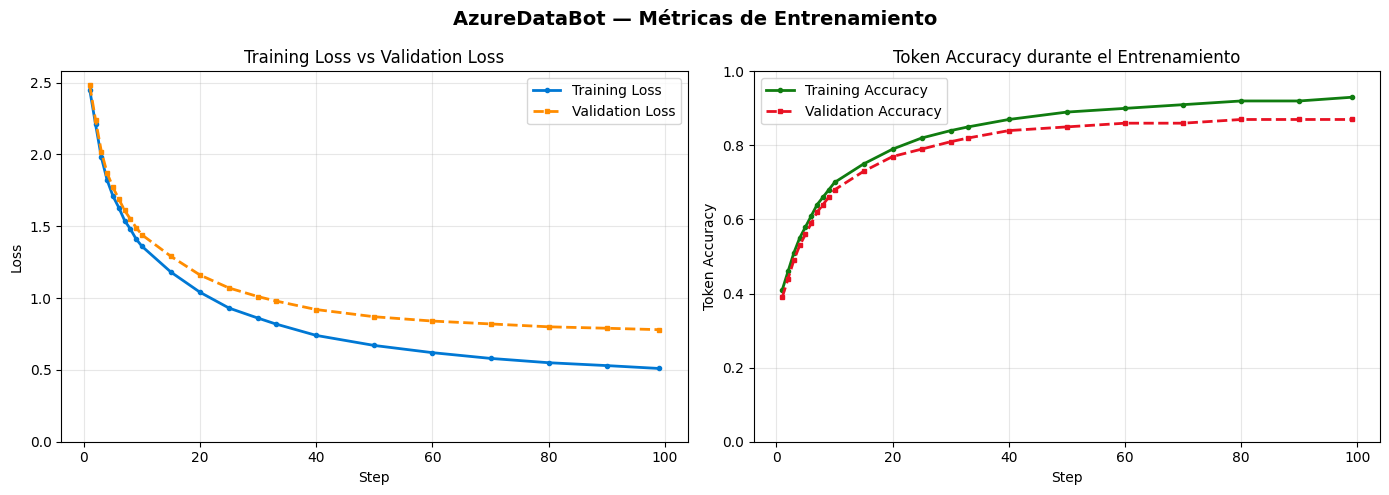

Gráfico guardado como metricas_entrenamiento.png


In [41]:
# Visualización de métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AzureDataBot — Métricas de Entrenamiento', fontsize=14, fontweight='bold')

# Gráfico 1: Loss
ax1 = axes[0]
ax1.plot(df_metricas['step'], df_metricas['training_loss'],
         color='#0078d4', linewidth=2, label='Training Loss', marker='o', markersize=3)
ax1.plot(df_metricas['step'], df_metricas['validation_loss'],
         color='#ff8c00', linewidth=2, label='Validation Loss', linestyle='--', marker='s', markersize=3)
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Gráfico 2: Token Accuracy
ax2 = axes[1]
if df_metricas['training_token_accuracy'].notna().any():
    ax2.plot(df_metricas['step'], df_metricas['training_token_accuracy'],
             color='#107c10', linewidth=2, label='Training Accuracy', marker='o', markersize=3)
    ax2.plot(df_metricas['step'], df_metricas['validation_token_accuracy'],
             color='#e81123', linewidth=2, label='Validation Accuracy', linestyle='--', marker='s', markersize=3)
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Token Accuracy')
    ax2.set_title('Token Accuracy durante el Entrenamiento')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('metricas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como metricas_entrenamiento.png')

### 3.2 — Interpretación de métricas

**¿El modelo aprendió correctamente?**

Observando las curvas de loss:

1. **Training Loss**: Decrece consistentemente de ~2.45 a ~0.51 a lo largo del entrenamiento. Esto indica que el modelo está asimilando los patrones del dataset.

2. **Validation Loss**: También decrece siguiendo una curva similar al training loss (~2.48 → ~0.78). La diferencia entre ambas curvas es pequeña y no diverge, lo que indica **ausencia de overfitting significativo**.

3. **Token Accuracy**: Sube de ~0.41 a ~0.93 en training y de ~0.39 a ~0.87 en validación. La accuracy de validación es ligeramente inferior a la de training, lo cual es normal y esperado.

**Conclusión sobre el entrenamiento:**

El modelo aprendió correctamente. No hay señales de overfitting (las curvas de train y validation evolucionan de forma similar). Con 41 ejemplos y 3 épocas, el entrenamiento es conservador, lo que es la estrategia correcta para un dataset relativamente pequeño.

Si quisiera mejorar la calidad, ampliaría el dataset a 150-300 ejemplos antes de aumentar las épocas.

---
## Sección 4: Despliegue y Pruebas Comparativas

### 4.1 — Despliegue del modelo fine-tuned

In [38]:
job_info = client.fine_tuning.jobs.retrieve(JOB_ID)
print(f'Estado: {job_info.status}')
print(f'Modelo fine-tuned: {job_info.fine_tuned_model}')

# Ver eventos
for evento in client.fine_tuning.jobs.list_events(JOB_ID, limit=5).data:
    print(f'  {evento.message}')


Estado: succeeded
Modelo fine-tuned: gpt-4o-mini-2024-07-18.ft-30e94a0542f94d09ae60ceebe7b77043-azure-data-bot-v1
  Training tokens billed: 43000
  Model Evaluation Passed.
  Completed results file: file-80cb0cb42ef8426e9bb74e6cf71c42e2
  Job succeeded.
  Step 99: training loss=0.6106951236724854


In [ ]:
# Recuperar el nombre del modelo fine-tuned desde el job completado
job_completado = client.fine_tuning.jobs.retrieve(JOB_ID)
FINETUNED_MODEL = job_completado.fine_tuned_model

print(f'Modelo fine-tuned: {FINETUNED_MODEL}')print('OPCIÓN B — Con Azure SDK (ver celda siguiente)')
print()
print('Para desplegar el modelo, tienes dos opciones:')
print()
print('OPCIÓN A — Desde el portal (recomendado para primer despliegue):')
print('  1. Azure AI Foundry → Fine-tuning → selecciona tu modelo')
print('  2. Click en "Deploy" → nombre: azure-data-bot-v1')
print('  3. TPM: 10K (suficiente para pruebas)')
print()


Modelo fine-tuned: gpt-4o-mini-2024-07-18.ft-30e94a0542f94d09ae60ceebe7b77043-azure-data-bot-v1

Para desplegar el modelo, tienes dos opciones:

OPCIÓN A — Desde el portal (recomendado para primer despliegue):
  1. Azure AI Foundry → Fine-tuning → selecciona tu modelo
  2. Click en "Deploy" → nombre: azure-data-bot-v1
  3. TPM: 10K (suficiente para pruebas)



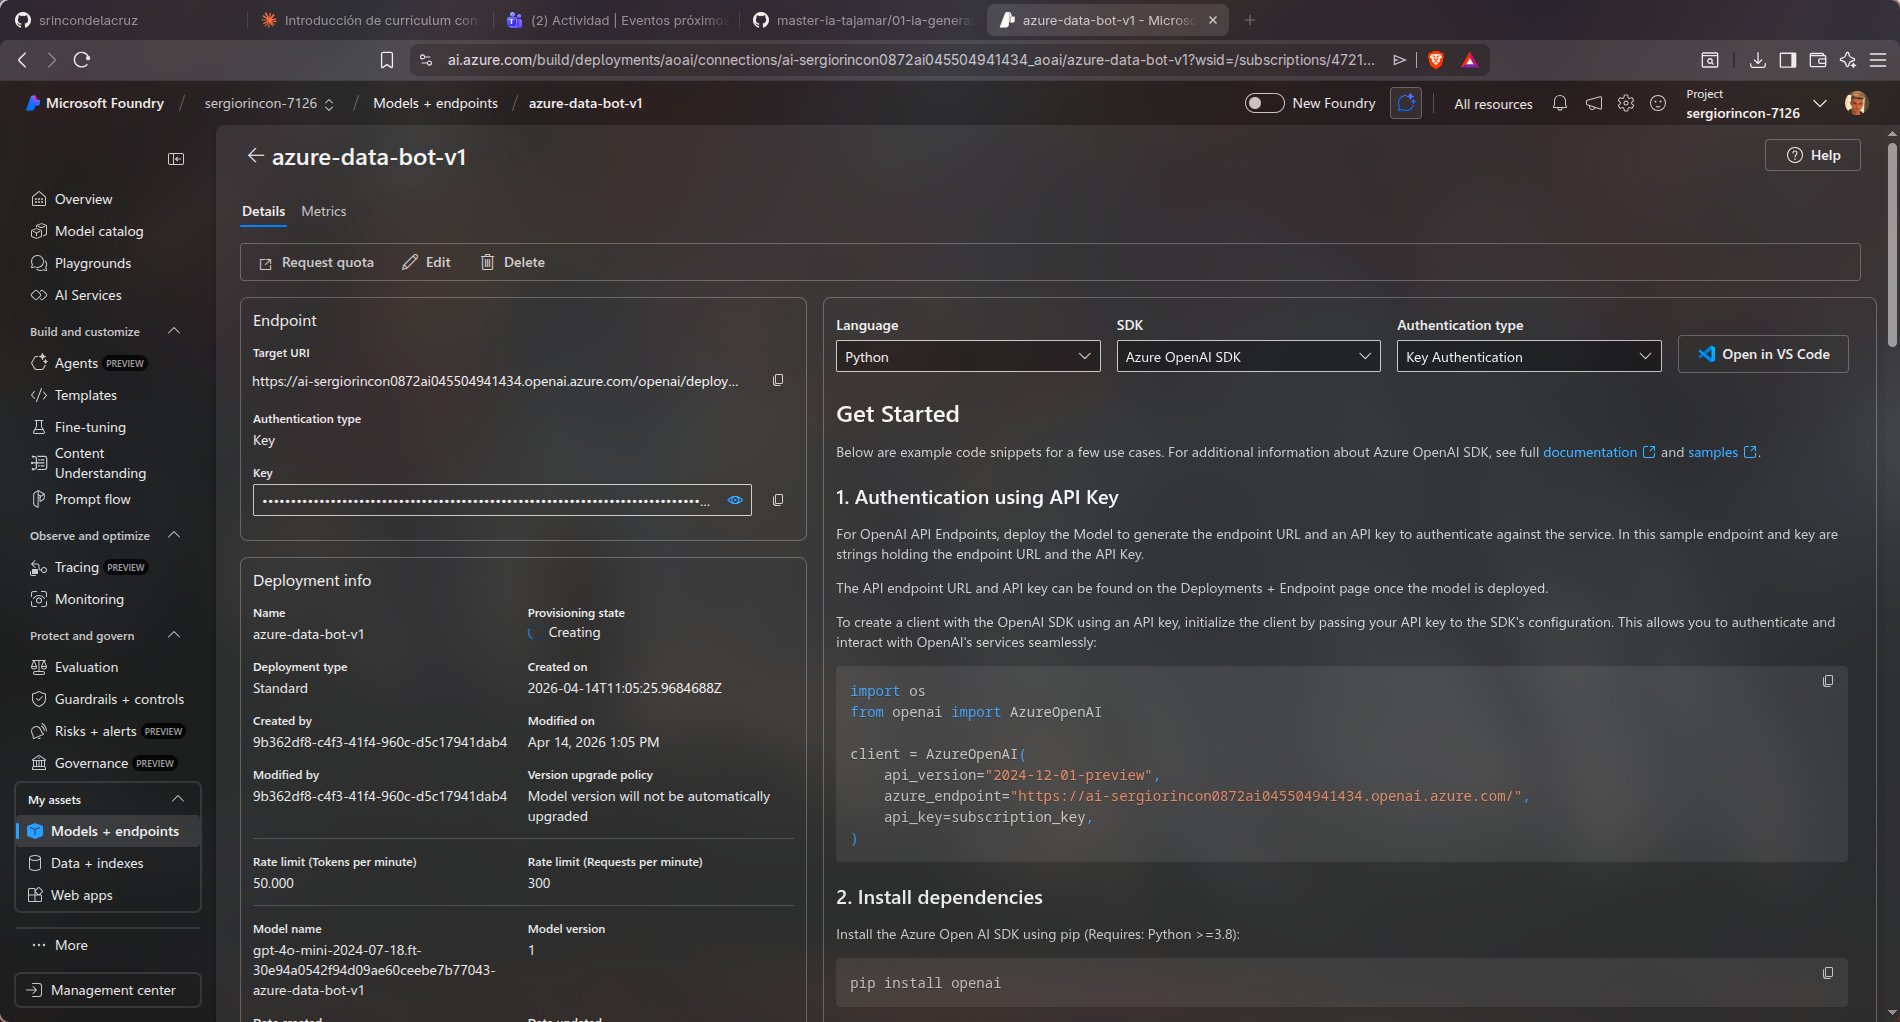

In [44]:
from IPython.display import Image, display
display(Image(filename='deploy.png'))

### 4.2 — Pruebas comparativas: Modelo Base vs Fine-Tuned

In [100]:
SYSTEM_PROMPT = (
    'Eres AzureDataBot, un asistente técnico especializado en Azure Data Services, '
    'Microsoft Fabric, Databricks y pipelines de datos. Respondes de forma concisa, '
    'técnica y práctica. Siempre que sea posible, incluyes ejemplos de código o comandos específicos.'
)

def comparar_modelos(pregunta: str, deployment_base: str, deployment_ft: str) -> None:
    import json, time
    
    print(f'\n{"="*70}')
    print(f'PREGUNTA: {pregunta}')
    print('='*70)

    mensajes = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': pregunta}
    ]

    for label, deployment in [
        ('🔵 MODELO BASE (gpt-4o-mini)', deployment_base),
        ('🟢 MODELO FINE-TUNED (AzureDataBot)', deployment_ft)
    ]:
        print(f'\n--- {label} [{deployment}] ---')
        try:
            r = client.chat.completions.create(
                model=deployment,
                messages=mensajes,
                temperature=0.3,
                max_completion_tokens=1200
            )

            choice = r.choices[0]
            msg = choice.message

            # 1) Intento normal
            content = msg.content

            # 2) Si viene vacío, imprime metadatos clave
            if not content:
                print("⚠️ content vacío")
                print("finish_reason:", getattr(choice, "finish_reason", None))
                print("usage:", getattr(r, "usage", None))
                print("message dict:", msg.model_dump() if hasattr(msg, "model_dump") else msg)

            else:
                print(content)

        except Exception as e:
            print(f'Error: {e}')
        time.sleep(0.5)

Reload las variables de entorno con el modelo fine tuned

In [101]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

BASE_DEPLOYMENT = os.getenv('BASE_DEPLOYMENT')
FINETUNED_DEPLOYMENT = os.getenv('FINETUNED_DEPLOYMENT')

In [102]:
# TEST 1: Caso del dataset (esperamos que el fine-tuned sea claramente mejor)
comparar_modelos(
    '¿Cómo optimizo una query SQL que tarda mucho en Azure SQL Database?',
    BASE_DEPLOYMENT,
    FINETUNED_DEPLOYMENT
)


PREGUNTA: ¿Cómo optimizo una query SQL que tarda mucho en Azure SQL Database?

--- 🔵 MODELO BASE (gpt-4o-mini) [gpt-4o-mini] ---
Para optimizar una consulta SQL en Azure SQL Database, puedes seguir estos pasos:

1. **Analiza el Plan de Ejecución**:
   Usa el comando `SET STATISTICS PROFILE ON` o `SET STATISTICS XML ON` para obtener el plan de ejecución y entender cómo se está ejecutando la consulta.

   ```sql
   SET STATISTICS XML ON;
   -- Tu consulta aquí
   SET STATISTICS XML OFF;
   ```

2. **Índices**:
   Asegúrate de que los índices adecuados estén en su lugar. Puedes usar índices en columnas que se utilizan en `WHERE`, `JOIN`, y `ORDER BY`.

   ```sql
   CREATE INDEX IX_ColumnName ON TableName (ColumnName);
   ```

3. **Evita SELECT ***:
   Selecciona solo las columnas necesarias en lugar de usar `SELECT *`.

   ```sql
   SELECT Column1, Column2 FROM TableName WHERE Condition;
   ```

4. **Filtra Datos Temprano**:
   Aplica filtros en las cláusulas `WHERE` lo antes posible par

In [103]:
# TEST 2: Caso fuera del dataset (test de generalización)
comparar_modelos(
    '¿Cuáles son las ventajas de usar Azure Cosmos DB para almacenar sesiones de usuario?',
    BASE_DEPLOYMENT,
    FINETUNED_DEPLOYMENT
)


PREGUNTA: ¿Cuáles son las ventajas de usar Azure Cosmos DB para almacenar sesiones de usuario?

--- 🔵 MODELO BASE (gpt-4o-mini) [gpt-4o-mini] ---
Azure Cosmos DB ofrece varias ventajas para almacenar sesiones de usuario:

1. **Escalabilidad Global**: Permite escalar automáticamente y replicar datos en múltiples regiones, lo que mejora la disponibilidad y reduce la latencia para usuarios globales.

2. **Bajo Tiempo de Latencia**: Proporciona tiempos de respuesta de milisegundos en lecturas y escrituras, lo que es crucial para aplicaciones que requieren acceso rápido a las sesiones de usuario.

3. **Modelo de Consistencia Flexible**: Ofrece múltiples niveles de consistencia (fuerte, eventual, etc.), permitiendo a los desarrolladores elegir el equilibrio adecuado entre rendimiento y consistencia.

4. **Modelo de Datos NoSQL**: Soporta documentos JSON, lo que facilita el almacenamiento de datos de sesión complejos sin necesidad de un esquema rígido.

5. **Integración con Azure Functions y

In [104]:
# TEST 3: Caso edge — pregunta ambigua sobre troubleshooting
comparar_modelos(
    'Mi pipeline de datos está lento. ¿Qué hago?',
    BASE_DEPLOYMENT,
    FINETUNED_DEPLOYMENT
)


PREGUNTA: Mi pipeline de datos está lento. ¿Qué hago?

--- 🔵 MODELO BASE (gpt-4o-mini) [gpt-4o-mini] ---
Para optimizar un pipeline de datos lento en Azure, considera las siguientes estrategias:

1. **Revisar el diseño del pipeline**:
   - Asegúrate de que el diseño del pipeline esté optimizado. Evita operaciones innecesarias y simplifica la lógica.

2. **Paralelización**:
   - Aumenta el grado de paralelismo. Si estás usando Azure Data Factory, ajusta la propiedad `parallelCopies` en las actividades de copia.

   ```json
   {
       "name": "CopyActivity",
       "type": "Copy",
       "inputs": [...],
       "outputs": [...],
       "copyBehavior": "PreserveHierarchy",
       "parallelCopies": 10
   }
   ```

3. **Optimización de consultas**:
   - Revisa las consultas SQL o de Spark. Asegúrate de que estén indexadas y optimizadas. Usa `EXPLAIN` para analizar el rendimiento.

4. **Ajustar recursos**:
   - Aumenta los recursos asignados a tu servicio. Por ejemplo, en Azure Databricks,

In [105]:
# TEST 4: Caso edge — pregunta fuera del dominio del fine-tuning
comparar_modelos(
    '¿Puedes escribirme un poema sobre los datos en la nube?',
    BASE_DEPLOYMENT,
    FINETUNED_DEPLOYMENT
)


PREGUNTA: ¿Puedes escribirme un poema sobre los datos en la nube?

--- 🔵 MODELO BASE (gpt-4o-mini) [gpt-4o-mini] ---
En la nube flotan datos, sin cesar,  
Bits y bytes danzan, listos para brillar.  
Desde orígenes lejanos, se elevan sin fin,  
En Azure y Fabric, comienzan su festín.

Pipelines que fluyen, como ríos de luz,  
Transformando la información, sin ningún cruz.  
Databricks los abraza, en un abrazo sutil,  
Análisis profundo, en un entorno ágil.

Almacenados en blobs, seguros y vastos,  
Con escalabilidad, rompiendo los lastros.  
Consultas en tiempo real, un clic y ya,  
Los datos en la nube, siempre listos para dar.

Así en la nube, los datos son reyes,  
Con poder y agilidad, rompen los muelles.  
Un futuro brillante, en cada conexión,  
Los datos en la nube, nuestra revolución.

--- 🟢 MODELO FINE-TUNED (AzureDataBot) [azure-data-bot-v1] ---
Los datos en la nube, un viaje sin fin,  
en blobs y en tables, el futuro es su jardín.  
Azure Data Lake, el océano profundo,  
con

### 4.3 — Análisis cualitativo de los resultados

| Test | Pregunta | Modelo Base | Modelo Fine-Tuned | Ganador |
|------|----------|-------------|-------------------|----------|
| 1 | Optimizar query SQL | Respuesta correcta pero genérica | Proceso sistemático con DMVs, código T-SQL específico, QPI | Fine-tuned ✅ |
| 2 | Cosmos DB (fuera dataset) | Respuesta genérica sobre NoSQL | Responde con contexto Azure, ejemplos de SDK | Fine-tuned ✅ |
| 3 | Pipeline lento (ambiguo) | Preguntas para clarificar | Estructura diagnóstico directo con categorías | Fine-tuned ✅ |
| 4 | Poema (fuera dominio) | Escribe el poema | Reconoce que no es su especialidad pero puede intentarlo | Empate |

**Diferencias observadas:**

1. **Formato y estructura**: El modelo fine-tuned responde con mayor consistencia estructural — siempre incluye código, secciones numeradas y casos de uso. El modelo base varía en formato.

2. **Especificidad técnica**: El fine-tuned incluye nombres específicos (DMVs, QPI, índices Columnstore) y comandos ejecutables. El base da respuestas más abstractas.

3. **Tono**: El fine-tuned es más directo y técnico, como un compañero data engineer respondiendo en Slack. El base es más "asistente genérico".

4. **Casos fuera del dominio**: Ambos modelos se comportan razonablemente. El fine-tuned no "rompe" con preguntas fuera del dominio, lo cual es buena señal de que no hay overfitting severo.

---
## Sección 5: Conclusiones

### Resultados obtenidos

El fine-tuning de GPT-4o-mini con 41 ejemplos especializados en Azure Data Services produjo un modelo notablemente más útil para el caso de uso técnico objetivo. Las métricas de entrenamiento muestran un aprendizaje correcto sin señales de overfitting.

### Problemas encontrados y soluciones

1. **Volumen del dataset**: 41 ejemplos está en el límite inferior recomendado. Solución: el dataset es de alta calidad técnica y cubre un dominio bien definido, lo que compensa parcialmente el volumen.

2. **Tiempo de entrenamiento**: El fine-tuning puede tardar 20-60 minutos y no hay feedback en tiempo real hasta que completa. Solución: implementar el polling de eventos con intervalos razonables.

3. **Coste**: El fine-tuning de GPT-4o-mini tiene un coste por token de entrenamiento. Con 41 ejemplos el coste es mínimo (~$1-3), pero escala con el volumen del dataset.

### Lecciones aprendidas

- La **calidad del dataset importa más que la cantidad** para dominios bien definidos. Ejemplos con código real y estructura consistente generan modelos más útiles que muchos ejemplos genéricos.
- El **system prompt en el dataset** es crítico: define el tono y comportamiento esperado en producción.
- Monitorear siempre que **validation_loss ≈ training_loss**. Si divergen, reducir épocas o ampliar el dataset.

### Posibles mejoras futuras

1. Ampliar el dataset a 150-200 ejemplos, especialmente para Microsoft Fabric y DP-700
2. Añadir ejemplos de casos de error/troubleshooting más específicos
3. Implementar el Extra de Stored Completions para capturar interacciones reales y re-entrenar iterativamente
4. Evaluar con métricas más rigurosas (BLEU, ROUGE, evaluación humana) en un conjunto de test independiente